# TSMAI ex5

In [123]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from scipy.optimize import root_scalar

## Task 1.

### 1.1.

In [124]:
def find_all_roots(func,func_prime,args,search_range=(-10, 10), n_guesses=20, maxtol=1e-44):
    roots = set()
    for guess in np.linspace(search_range[0], search_range[1], n_guesses):
        try:
            result = root_scalar(
                func,
                fprime=func_prime,
                args=args,  # Tuple of (w_val, theta_val)
                x0=float(guess),
                method='newton'
            )
            if result.converged:
                roots.add(round(result.root, 8))
        except:
            continue
    if not result.converged:
        #print("#########################################################")
        x_guesses = np.linspace(search_range[0], search_range[1], n_guesses)
        for i, guess in enumerate(x_guesses):
            # Create a small bracket around the guess point
            left = max(search_range[0], guess - 1.0)  # 1.0 is bracket width
            right = min(search_range[1], guess + 1.0)
            
            # Verify sign change (required for brentq)
            f_left = func(left, *args)
            f_right = func(right, *args)
            
            if f_left * f_right < 0:  # Valid bracket
                try:
                    result = root_scalar(
                        func,
                        args=args,
                        bracket=[left, right],
                        method='brentq',
                        xtol=maxtol,
                        rtol=maxtol
                    )
                    if result.converged:
                        roots.add(round(result.root, 8))
                except:
                    continue
            
    return np.array(sorted(roots)), result.converged

In [179]:
class Map:
    def __init__(self, expr, params,order): # dynamic variables first
        self.params = params
        self.expr = expr
        self.lhs = expr.lhs
        self.func = sym.lambdify((params), self.lhs, modules=['numpy'])
        self.order_tupl = tuple(order.split())
        self.fp_vals = 'call FP method first'

        self.prime_expr = sym.diff(self.lhs, params[0])
        self.prime_expr_func = sym.lambdify((params[0], *self.params[1:]), self.prime_expr, modules=['numpy'])
        
        
    def __call__(self, param_vals: dict):

        param_val_tupl = tuple(param_vals[key] for key in self.order_tupl)

        return self.func(*param_val_tupl)
    
    def FP_num(self,initial_guess=0.0,default_params=None,plot=False,maxtol=1e-4):
        x = self.params[0]
        FP_eq = sym.Eq(x,self.lhs)

        
        g = FP_eq.lhs - FP_eq.rhs
        fp_func = sym.lambdify((x, *self.params[1:]), g, modules=['numpy'])
        prime_func = sym.lambdify((x, *self.params[1:]), sym.diff(g, x), modules=['numpy'])
        
        args = [default_params[key] for key in self.order_tupl]
        args = tuple(args[1:])

        roots, converged = find_all_roots(fp_func,prime_func,args,search_range=(-10, 10), n_guesses=20,maxtol=maxtol)

        # result = root_scalar(
        #     fp_func,
        #     fprime=prime_func,
        #     args=args,
        #     x0=float(initial_guess),
        #     method='newton'
        # )
        
        if converged:
            self.fp_vals = roots
            
            if plot:
                x_arr = np.linspace(-10,10,100)
                plt.plot(x_arr, self(default_params),label='map')
                plt.plot(x_arr,x_arr,label='bisectrix')
                plt.scatter(roots,roots,label='FP',color='g')
                plt.title('expression return plot')
                plt.xlabel('x_{n}')
                plt.ylabel('x_{n+1}')
                plt.legend()
                plt.show()

            return roots
        else:
            print('did not converge')
            print("here is a plot: ")
            x_arr = np.linspace(-10,10,100)
            plt.plot(x_arr, self(default_params))
            plt.plot(x_arr,x_arr)
            plt.title('expression return plot')
            plt.show()
    
    
    def FP(self,initial_guess=0.0,default_params=None,plot=False,maxtol=1e-4):
        x = self.params[0]
        FP_eq = sym.Eq(x,self.lhs)

        try:
            fp_solutions = sym.solve(FP_eq,x)

            if fp_solutions:
                other_params = [p for p in self.params if p != x]
                self.FP_func = sym.lambdify(other_params, fp_solutions[0], modules=['numpy'])

                return fp_solutions
        except Exception as e:
            print(f"Could not find fixed point symbolically: {e}")

            
            roots = self.FP_num(initial_guess=initial_guess,default_params=default_params,plot=plot,maxtol=maxtol)

            return roots
            
        
        return None

    
    def stability(self,param_vals,prints=False):
        if type(self.fp_vals) == str:
            print(self.fp_vals)

        param_val_tupl = tuple(param_vals[key] for key in self.order_tupl)
        #print(param_val_tupl)

        local_slope = self.prime_expr_func(*param_val_tupl)
        abs_slope = abs(local_slope)

        stab_list = []

        for i,slope in enumerate(abs_slope):
            if prints:
                if slope > 1: 
                    print(f'Unstable fp because local slope is |{local_slope}| > 1')
                elif slope < 1:
                    print(f'Stable because local slope is |{local_slope}| < 1')
                else: 
                    print(f'hihger order analysis needed because local slope is |{slope}| = 1')
            stab_list.append(slope < 1) # True stable, False unstable
        
        return local_slope, stab_list

    def k_iterate(self, k, simpl=False):
        x_current = self.params[0] # default
        for _ in range(k):
            x_current = self.lhs.subs(self.params[0], x_current)
        if simpl:
            return sym.simplify(x_current), sym.lambdify(self.params, x_current, 'numpy')
        else:
            return x_current, sym.lambdify(self.params, x_current, 'numpy')


Could not find fixed point symbolically: multiple generators [x, exp(x)]
No algorithms are implemented to solve equation x + (-theta - w/(1 + exp(-x)))


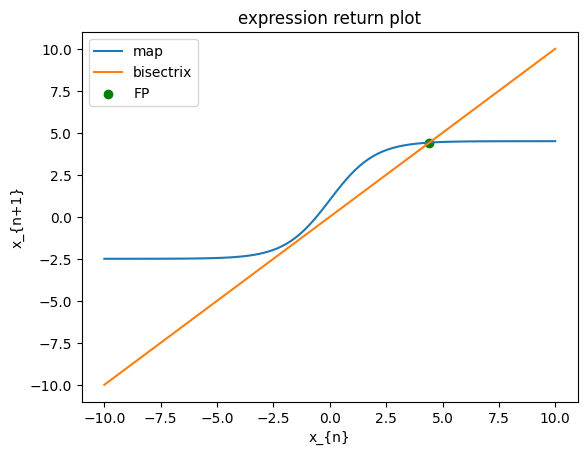

[4.41647135]
Stable because local slope is |[0.08253193]| < 1


In [126]:
x,w,theta = sym.symbols('x w theta')

expr = sym.Eq(w/(1+sym.exp(-x))+theta, 0) # lhs,rhs

# a = expr.free_symbols # set of symbols

MAP_task1 = Map(expr,[x,w,theta],'x w theta')
FPexpr = MAP_task1.FP(initial_guess=4.5,default_params={'x': np.linspace(-10,10,100),'w':7, 'theta':-2.5},plot=True)
print(MAP_task1.fp_vals)

FP_slope = MAP_task1.stability({'x':  MAP_task1.fp_vals,'w':7, 'theta':-2.5},prints=True)


### 1.2

In [127]:
from tqdm import tqdm

bifur_MAP = Map(expr,[x,w,theta],'x w theta')

theta_range = np.linspace(-10,0,1000)

FP_vals = []
theta_vals = []
colors = []

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    for theta_val in tqdm(theta_range):
        FPexpr = MAP_task1.FP_num(initial_guess=0,default_params={'x': np.linspace(-10,10,100),'w':7, 'theta':theta_val})
        

        if FPexpr is not None:
            theta = np.ones(len(FPexpr))*theta_val
            slope, stab_list = MAP_task1.stability({'x':  MAP_task1.fp_vals,'w':7, 'theta':theta_val})
            color = ['g' if stab else 'r' for stab in stab_list]
            FP_vals.extend(FPexpr)
            theta_vals.extend(theta)
            colors.extend(color)

100%|██████████| 1000/1000 [00:40<00:00, 24.94it/s]


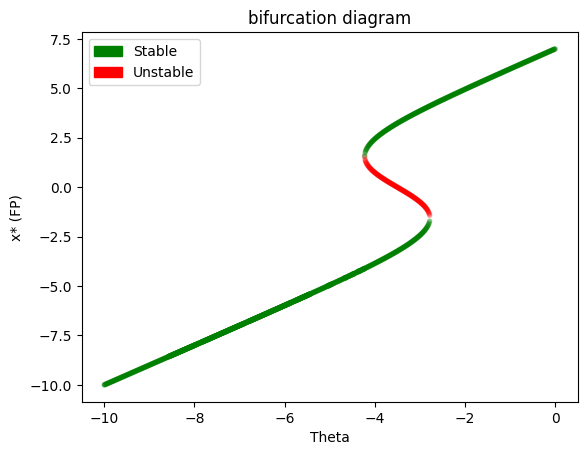

In [128]:
import matplotlib.patches as mpatches
plt.scatter(theta_vals,FP_vals,color=colors,alpha=0.3,marker='.')
plt.title('bifurcation diagram')
plt.xlabel('Theta')
plt.ylabel('x* (FP)')
green_patch = mpatches.Patch(color='g', label='Stable')
red_patch = mpatches.Patch(color='r', label='Unstable')
plt.legend(handles=[green_patch, red_patch])
plt.show()

## Task 2

### 2.2

In [180]:
x,r = sym.symbols('x r')

logis_eq = sym.Eq(r*x*(1-x), 0)


In [181]:
logistic_map = Map(logis_eq,[x,r],'x r')

In [151]:
def plot_map(map,param_dict,iter,Title=None):

    #x_vals = np.zeros(iter)
    fig, ax = plt.subplots(figsize=(12, 6))
    x = param_dict['x']
    x0 = x
    x_plot_vals = [x,0]
    x_min = x0
    x_max = x0
    for i in range(iter):
        if i == 0:
            x = map(param_dict)
            param_dict['x'] = x
            x_plot_vals[1] = x

            ax.plot([x_plot_vals[0],x_plot_vals[1]],[x_plot_vals[1],x_plot_vals[1]],color="green")
            if x < x_min:
                x_min = x
            if x > x_max:
                x_max = x 
        else:
            ax.plot([x_plot_vals[0],x_plot_vals[1]],[x_plot_vals[1],x_plot_vals[1]],color="green")
            x_plot_vals[0] = x_plot_vals[1]
            x = map(param_dict)
            param_dict['x'] = x

            x_plot_vals[1] = x
            ax.plot([x_plot_vals[0],x_plot_vals[0]],[x_plot_vals[0],x_plot_vals[1]],color="green")
            if x < x_min:
                x_min = x
            if x > x_max:
                x_max = x 
        
    x_plot = np.linspace(x_min,x_max,1000)
    ax.plot(x_plot,x_plot,label=f"x_n = x_(n+1)",color="blue")
    param_dict['x'] = x_plot
    ax.plot(x_plot,map(param_dict),label="f(x_n)",color="red")
    ax.legend()
    ax.set_title(Title)

    fig.show()


/var/folders/pd/2bgmf1pd7fv79_2hltggtpsw0000gn/T/ipykernel_54592/3392337712.py:41: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


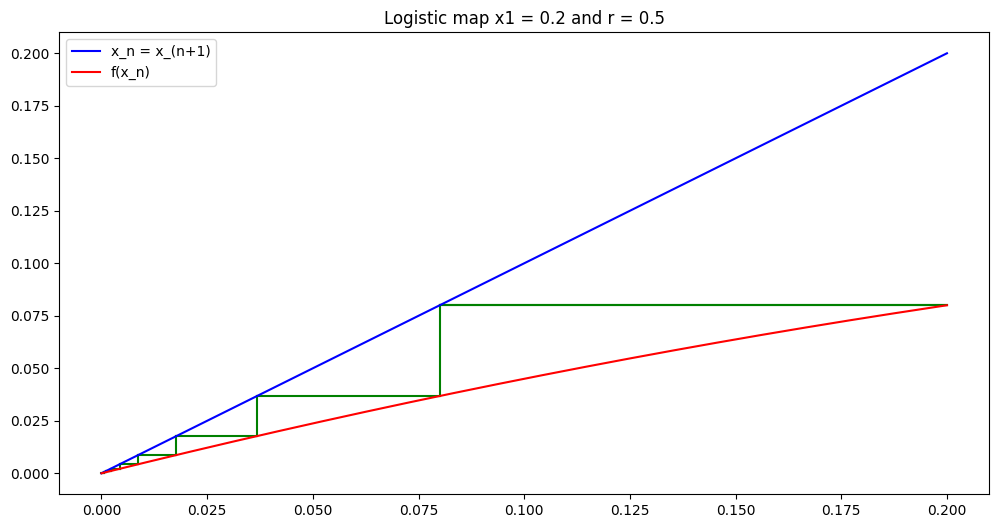

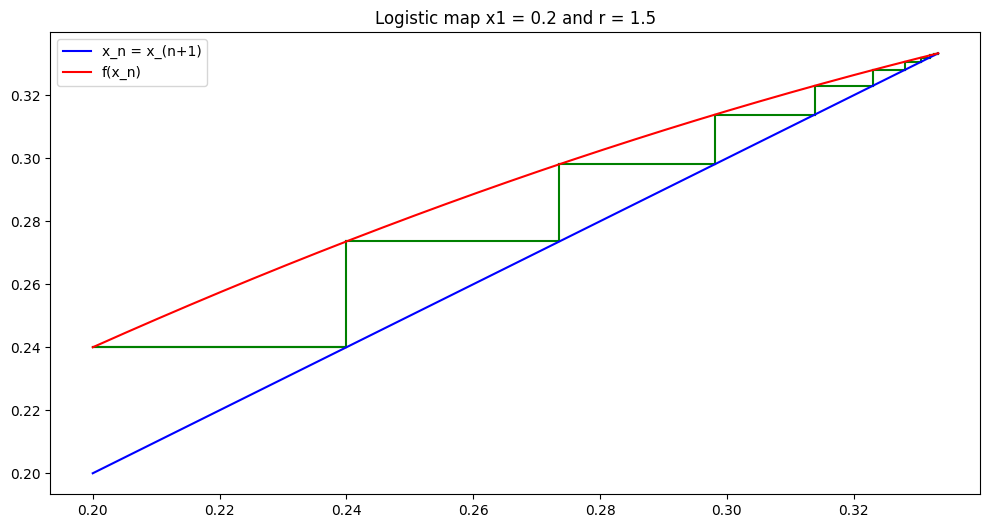

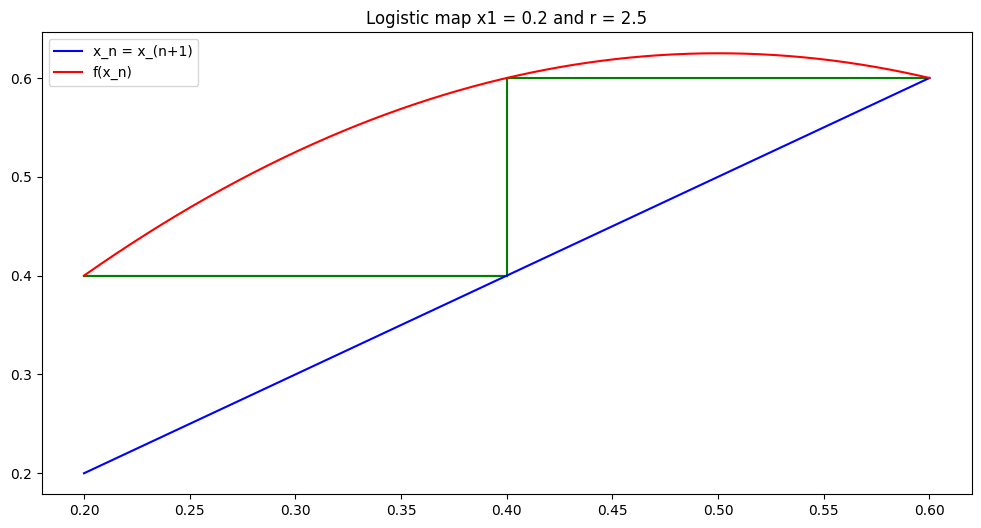

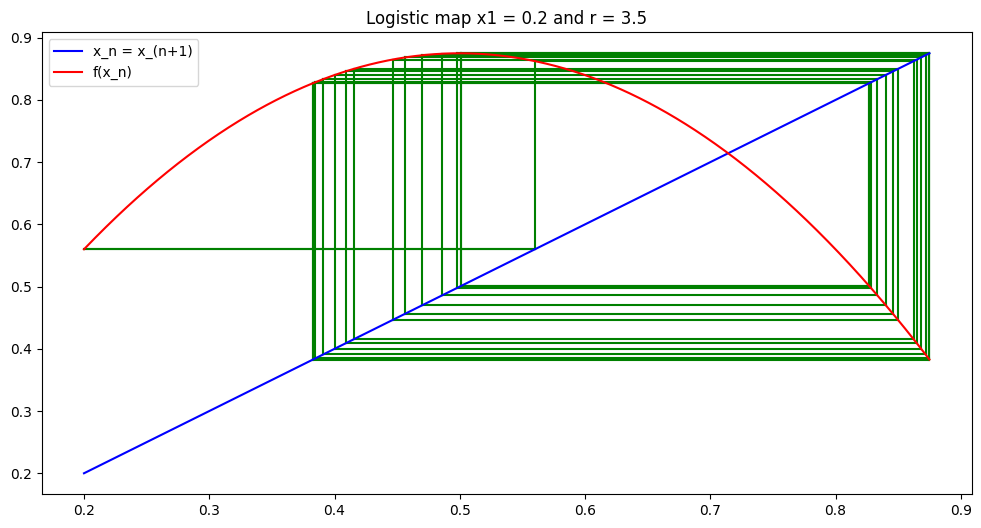

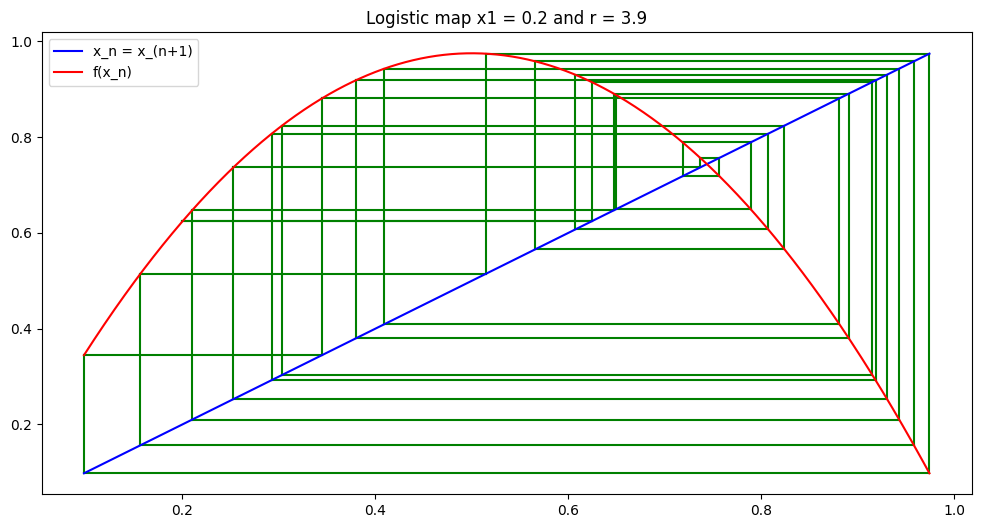

In [152]:
x0 = 0.2
r = [0.5, 1.5, 2.5, 3.5, 3.9]
for R in r:
    plot_map(logistic_map,{'x': x0,'r': R,},30,Title=f'Logistic map x1 = {x0} and r = {R}')

### 2.4

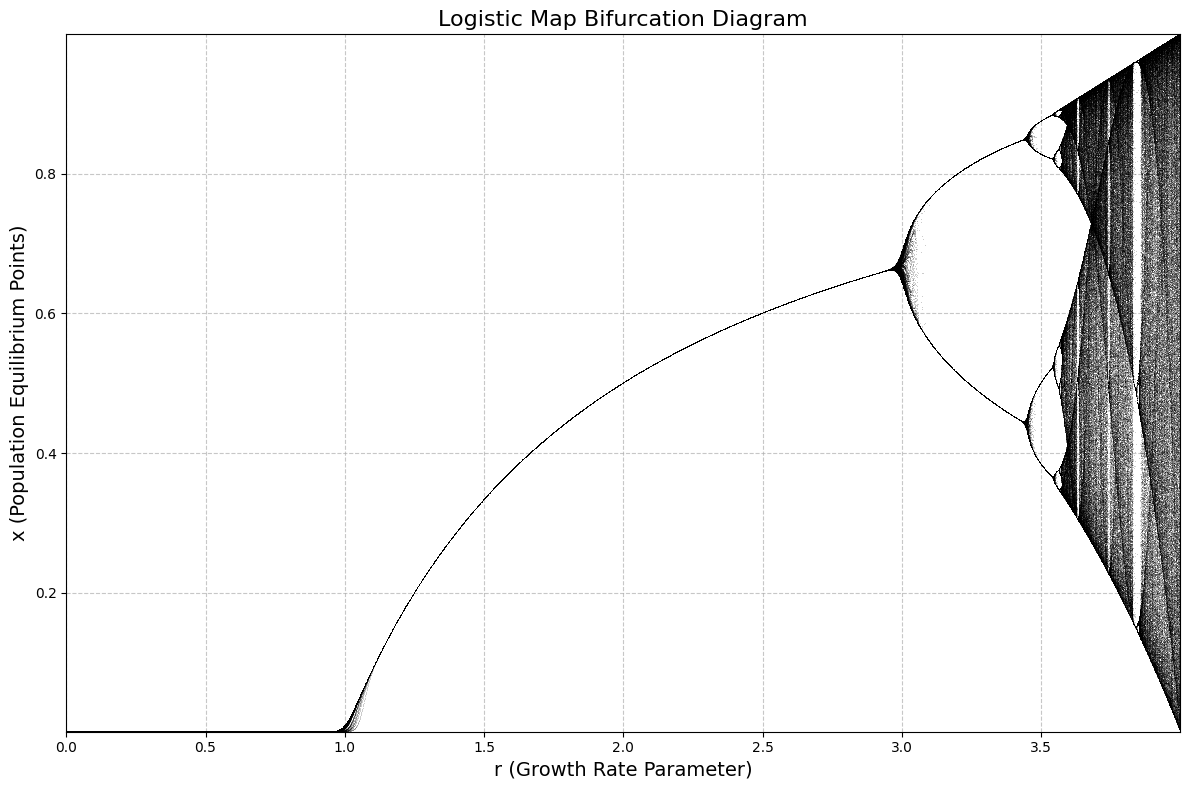

In [173]:
rand_x0 = np.random.rand(1000)

r_vals = np.arange(0,4,0.001)

len_traj = 100

dum_shape = np.ones(len(rand_x0))


x_plot = []
r_plot = []

for r in r_vals:
    param_dict = {'x':rand_x0,'r':r}
    for i in range(len_traj): 
        x = logistic_map(param_dict)
        param_dict['x'] = x
    
    x_plot.extend(x)
    r_plot.extend(r*dum_shape)
    #print(r)

plt.figure(figsize=(12,8))
plt.plot(r_plot, x_plot, ',', alpha=0.2, color='black') 

plt.title("Logistic Map Bifurcation Diagram", fontsize=16)
plt.xlabel("r (Growth Rate Parameter)", fontsize=14)
plt.ylabel("x (Population Equilibrium Points)", fontsize=14)
plt.xlim(r_vals.min(),r_vals.max())
plt.ylim(x.min(), x.max())
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

### 2.5

12500


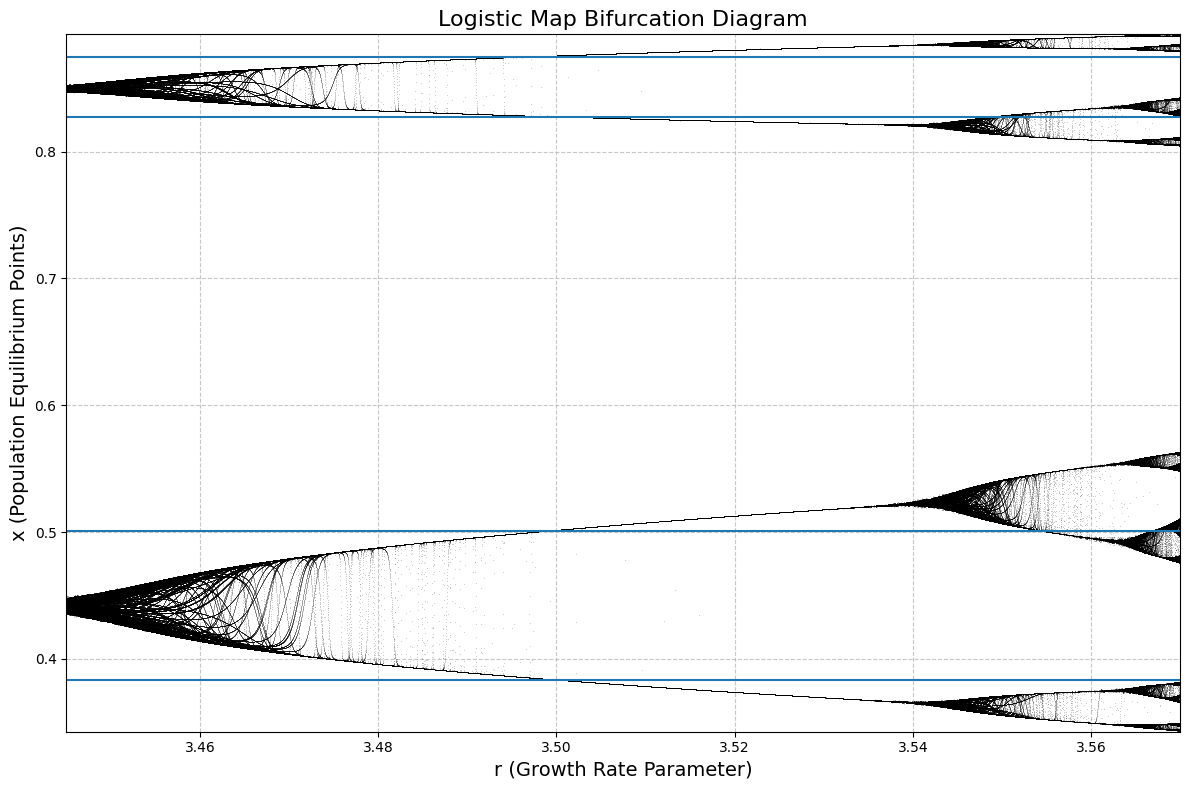

In [212]:

rand_x0 = np.random.rand(1000)

r_vals = np.arange(3.44500,3.57000,0.00001)

len_traj = 100

dum_shape = np.ones(len(rand_x0))
print(len(r_vals))

x_plot = []
r_plot = []

for r in r_vals:
    param_dict = {'x':rand_x0,'r':r}
    for i in range(len_traj): 
        x = logistic_map(param_dict)
        param_dict['x'] = x
    
    x_plot.extend(x)
    r_plot.extend(r*dum_shape)
    #print(r)

plt.figure(figsize=(12,8))
plt.plot(r_plot, x_plot, ',', alpha=0.2, color='black') 

plt.title("Logistic Map Bifurcation Diagram", fontsize=16)
plt.xlabel("r (Growth Rate Parameter)", fontsize=14)
plt.ylabel("x (Population Equilibrium Points)", fontsize=14)
plt.xlim(r_vals.min(),r_vals.max())
plt.ylim(x.min(), x.max())
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=0.8275)
plt.axhline(y=0.501)
plt.axhline(y=0.875)
plt.axhline(y=0.383)
plt.tight_layout()
plt.show()

The horizontal lines are used below to check the cycle.

Wibe coded (using Gemini 2.5 pro) a C version for some speed, and let the map iterate 5000 times per 1000 r samples such that values have a lot of time to converge to attractor and we get some cleaner plots. Got a bit carried away with the plots:)

In [ ]:
import pandas as pd

def plot_bifur_from_c(file,save=False,alpha=0.25,figsize=(12, 8)):
    # Read the bifurcation data
    try:
        df = pd.read_csv(file)
    except FileNotFoundError:
        print("Error: bifurcation_data.csv not found. Run the C program first.")
        exit()

    # Plotting
    plt.figure(figsize=figsize)
    plt.plot(df['r'], df['x'], ',', alpha=alpha, color='black') # Use ',' for small markers

    plt.title("Logistic Map Bifurcation Diagram", fontsize=16)
    plt.xlabel("r (Growth Rate Parameter)", fontsize=14)
    plt.ylabel("x (Population Equilibrium Points)", fontsize=14)
    plt.xlim(df['r'].min(), df['r'].max())
    plt.ylim(df['x'].min(), df['x'].max())
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    if save:
        save_name = file.rsplit('.', 1)[0] + '.png'
        plt.savefig(save_name, dpi=300)
        print(f"Bifurcation diagram plotted and saved as {save_name}")
    plt.show()

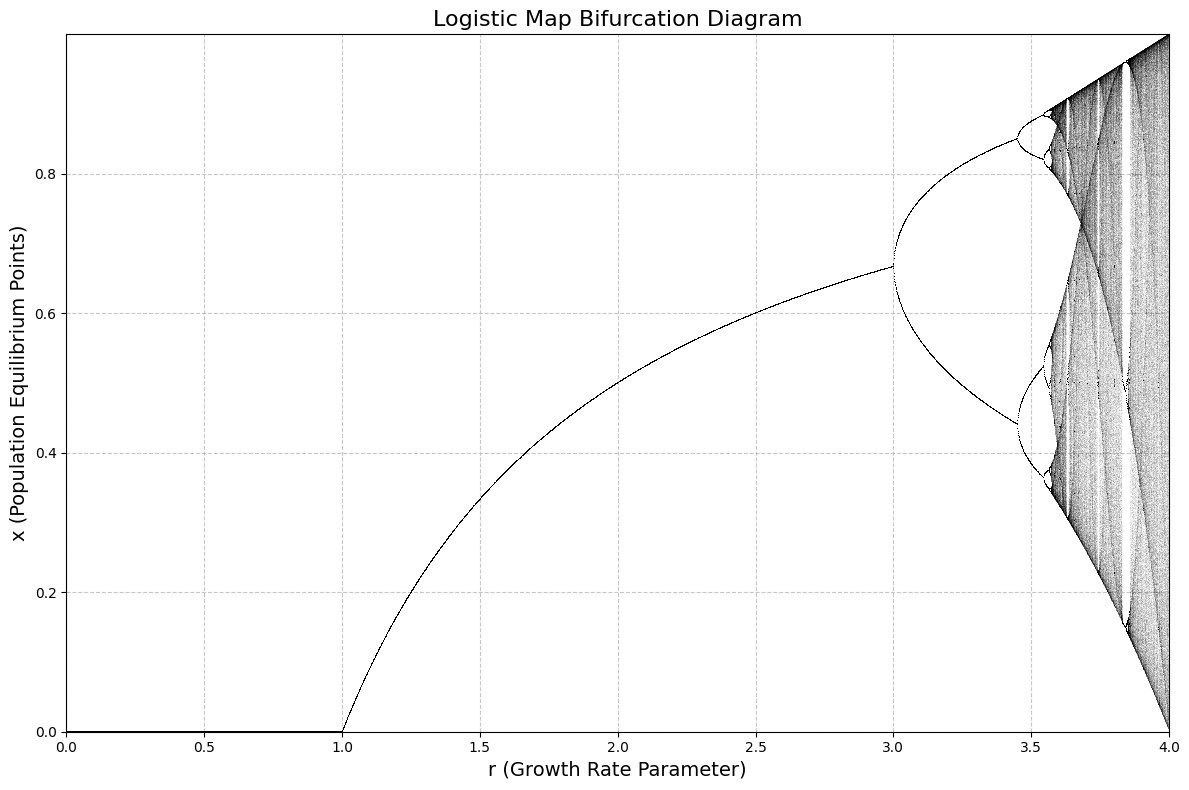

In [130]:
plot_bifur_from_c("bifurcation_data.csv",alpha=0.05)

### 2.5



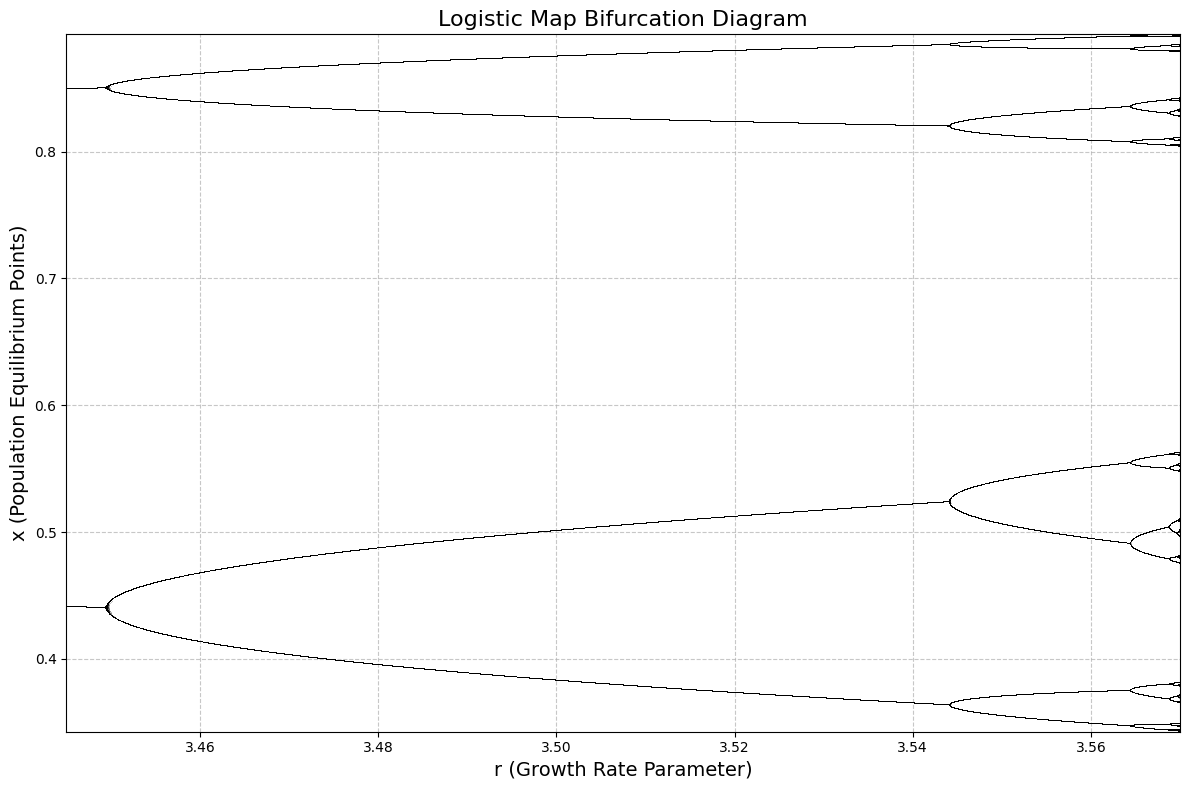

In [131]:
plot_bifur_from_c("endpoints_data_mpfr.csv")

### 2.5 still

We observe 4 branches for $r\approx3.5$ so there should be a 4 > p = 3 cycle. We verify mathematically by using sympy to create a $f^4(x)$ map and verify if $f^4(x) = x$

In [220]:
k3expr, k3logistic_funct = logistic_map.k_iterate(4)

print("checking the 4 cycle with values found visually for r = 3.5")
print(f'f^4(0.383) = {k3logistic_funct(x=0.383,r=3.5)}')
print(f'f^4(0.501) = {k3logistic_funct(x=0.501,r=3.5)}')
print(f'f^4(0.8275) = {k3logistic_funct(x=0.8275,r=3.5)}')
print(f'f^4(0.875)= {k3logistic_funct(x=0.875,r=3.5)}')

print("also checking with iterativly applying map")
x0 = 0.383
param_dict = {'x':x0, 'r':3.5}
for i in range(12):
    x = logistic_map(param_dict)
    param_dict['x'] = x
    print(round(x,3))
print('we clearly see a cycle of order 4, since 4 distict values repeat in a cyclic manner.')

checking the 4 cycle with values found visually for r = 3.5
f^4(0.383) = 0.3828152378945099
f^4(0.501) = 0.5008804475158373
f^4(0.8275) = 0.826936001536345
f^4(0.875)= 0.87499717950388
also checking with iterativly applying map
0.827
0.501
0.875
0.383
0.827
0.501
0.875
0.383
0.827
0.501
0.875
0.383
we clearly see a cycle of order 4, since 4 distict values repeat in a cyclic manner.


### some more pretty plots

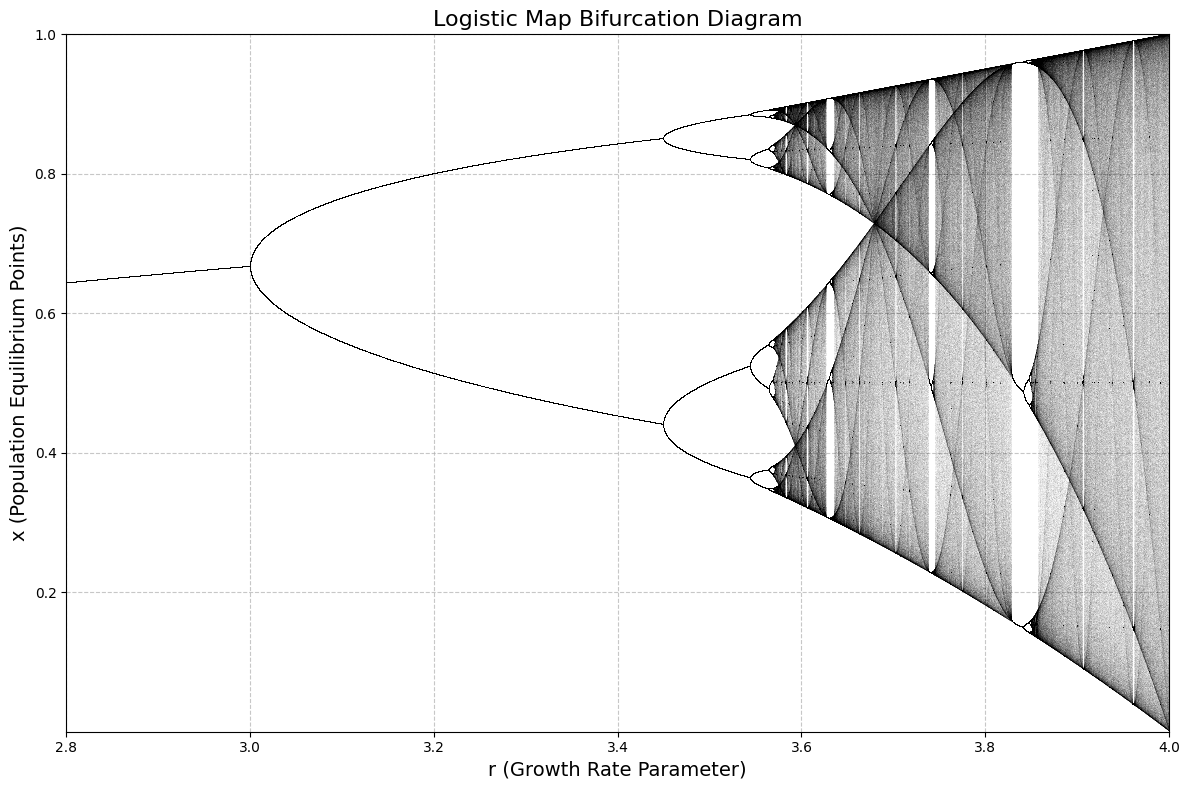

In [132]:
plot_bifur_from_c("endpoints_data.csv",alpha=0.02)

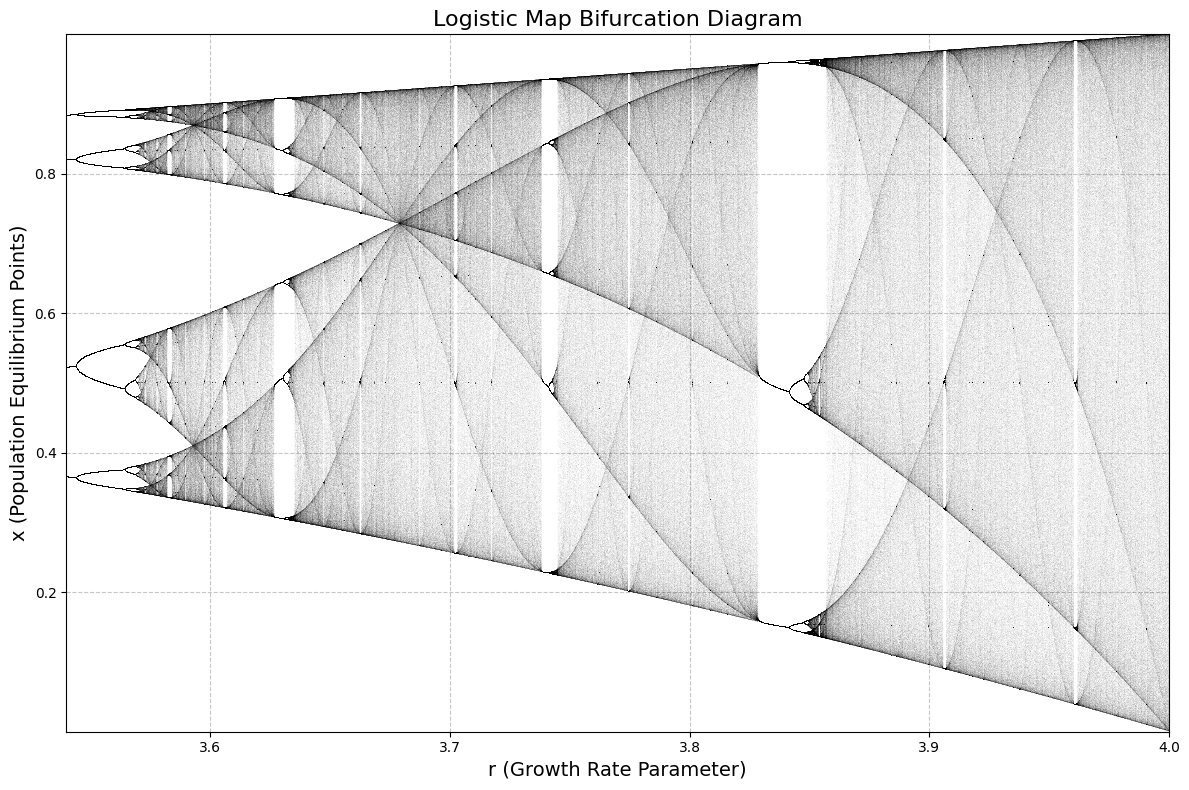

In [133]:
plot_bifur_from_c("endpoints_data_3_54_4.csv",alpha=0.02)

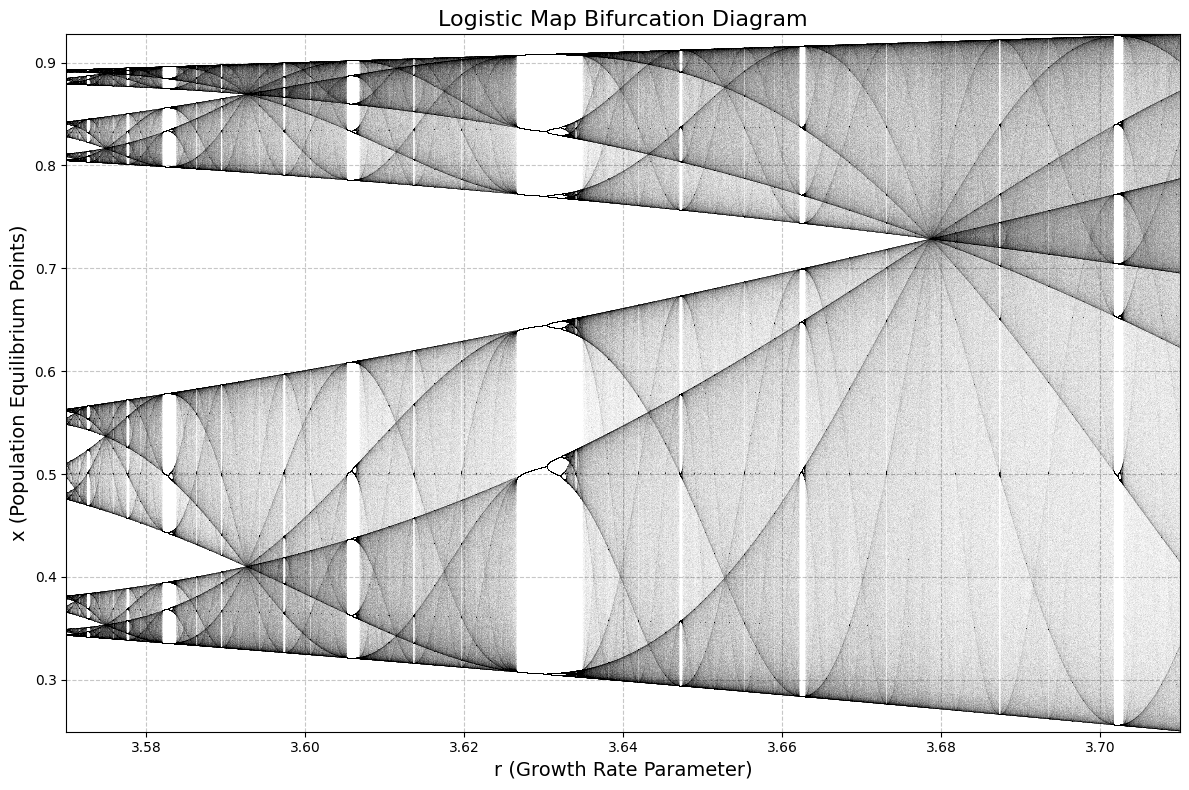

In [134]:
plot_bifur_from_c("endpoints_data_3_57__71.csv",alpha=0.01)

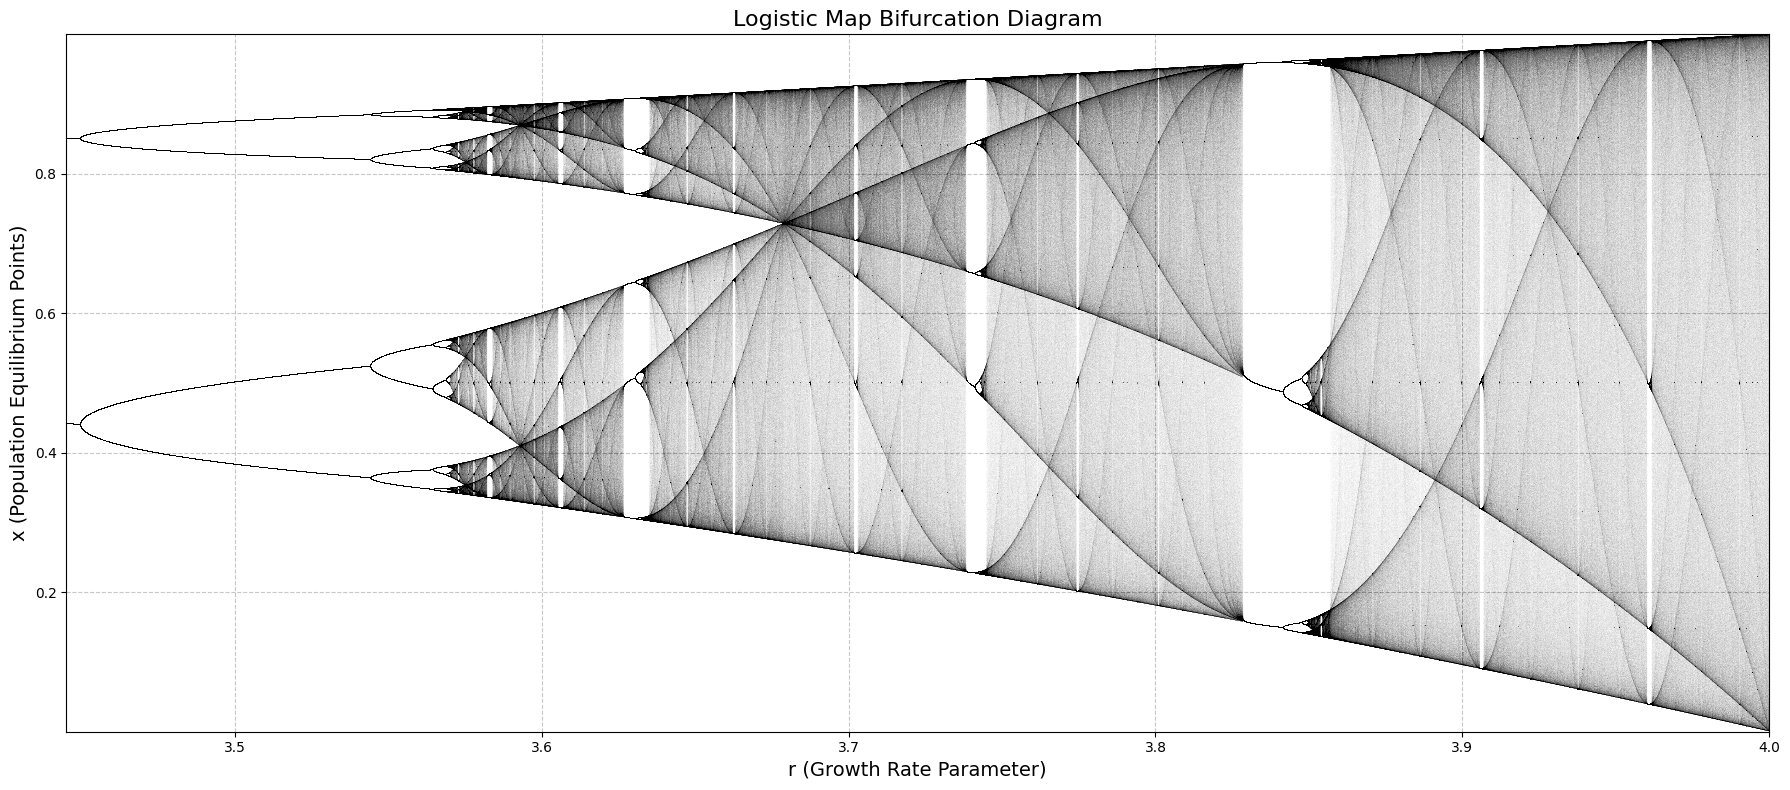

In [135]:
plot_bifur_from_c("endpoints_data_3_445_4.csv",alpha=0.008,figsize=(18,8))

### 2.6

In [ ]:
logistic_map_func = logistic_map.func
x = np.random.rand(1000)
for i in range(4000):
    x = logistic_map_func(x,r=3.5)

print(x.shape)



(1000,)


In [ ]:
def small_increment_r(warmup_len,analyse_traj_len,r_stepsize_init,min_r_increment):
    r_stepsize = np.float128(r_stepsize_init)
    found_bifur = False
    x_analyse = np.zeros(analyse_traj_len,dtype=np.float128)

    while distinct_x_vals < prev_distinct_vals:
        r += r_stepsize
        # init x vals
        x = np.float128(np.random.rand())
        r = np.float128(r)

        # warm up to reach attractor
        for i in range(warmup_len):
            x = logistic_map_func(x,r)
        
        # collect values to analyse
        for i in range(analyse_traj_len):
            x = logistic_map_func(x,r)
            x_analyse[i,:] = x

        distict_vals = set(np.round(x_analyse[0],7))
        #print(distict_vals)
        distinct_x_vals = len(distict_vals)

        # if r max reached, go back to previous bifur and lower r increment
        if r >= 4:
            r = r_last_bifur
            r_stepsize *= np.float128(0.5)
            if r_stepsize < min_r_increment:
                r_stepsize = min_r_increment
            print(r_stepsize)

    if distinct_x_vals > prev_distinct_vals:
        prev_distinct_vals = distinct_x_vals
        found_bifur = True  
        r_last_bifur = r
        write_value_to_file(r, filename)
        bifur_found += 1
        print(r)
    else:
        prev_distinct_vals += 1

In [ ]:

def find_distinct(sorted_arr, accuracy):
    """Count distinct values."""
    if len(sorted_arr) == 0:
        return 0
    distinct = 1
    current = sorted_arr[0]
    for val in sorted_arr[1:]:
        if abs(val - current) > max(accuracy * abs(current), accuracy):
            distinct += 1
            current = val
    return distinct

def find_bifur(r0, map_func, max_bifur_search, filename,
               warmup_len=10000,
               analyse_traj_len=5000,
               initial_min_r_increment=1e-5,
               accuracy_distinct=1e-10,
               tolerance_decay=0.5,
               min_dist_bifur=1e-5,
               min_r_increment_limit=1e-12):
    
    bifur_points = []
    r_current = r0
    min_r_increment = max(initial_min_r_increment, min_r_increment_limit)

    while len(bifur_points) < max_bifur_search:
        # Bisection setup
        r_low = r_current
        r_high = 4.0
        valid_bifur = False
        attempts = 0

        while not valid_bifur and attempts < 10:
            # Get initial distinct count at r_low
            x = np.random.rand()
            for _ in range(warmup_len):
                x = map_func(np.float128(x), np.float128(r_low))
            x_vals = np.zeros(analyse_traj_len, dtype=np.float128)
            for i in range(analyse_traj_len):
                x = map_func(np.float128(x), np.float128(r_low))
                x_vals[i] = x
            n_low = find_distinct(np.sort(x_vals), accuracy_distinct)

            # Bisection loop
            while r_high - r_low > min_r_increment:
                r_mid = (r_low + r_high) / 2.0

                # Compute distinct count at midpoint
                x = np.random.rand()
                for _ in range(warmup_len):
                    x = map_func(np.float128(x), np.float128(r_mid))
                x_vals = np.zeros(analyse_traj_len, dtype=np.float128)
                for i in range(analyse_traj_len):
                    x = map_func(np.float128(x), np.float128(r_mid))
                    x_vals[i] = x
                n_mid = find_distinct(np.sort(x_vals), accuracy_distinct)

                # Narrow interval
                if n_mid > n_low:
                    r_high = r_mid
                else:
                    r_low = r_mid

            candidate_point = np.float128(r_mid)
            
            # Enforce minimum distance and precision limits
            if bifur_points:
                if candidate_point != 4:
                    prev_point = bifur_points[-1]
                    distance = abs(candidate_point - prev_point)
                
                if distance < min_dist_bifur:
                    print(f"Adjusting precision: {distance:.2e} < {min_dist_bifur:.0e}")
                    min_r_increment = max(min_r_increment * 0.1, min_r_increment_limit)
                    attempts += 1
                    r_low = prev_point
                    r_high = 4.0
                    continue
                    
            valid_bifur = True

        if not valid_bifur:
            r_low = prev_point

        # Store valid bifurcation
        bifur_points.append(candidate_point)
        write_value_to_file(candidate_point, filename)
        print(f"Found bifurcation {len(bifur_points)} at {candidate_point:.12f}")

        # Update search parameters with decay limits
        if len(bifur_points) > 1:
            prev_interval = bifur_points[-1] - bifur_points[-2]
            min_r_increment = max(
                prev_interval * tolerance_decay,
                min_r_increment_limit
            )
        else:
            min_r_increment = max(
                initial_min_r_increment,
                min_r_increment_limit
            )

        r_current = candidate_point

    return bifur_points

def write_value_to_file(value, filename):
    with open(filename, 'a') as f:
        f.write(f"{value}\n")

def read_values_from_file(filename):
    return np.loadtxt(filename)

The code is an attemt at implementing a bisection method for finding qualitative differences in amount of unique points in the trajectory after it has been warmed up for a while to reach the attractor. It works by having an interval of r values, then calculate the amount of distinct values at the low and mid point of the interval, if they are the same an bifurcation comes after the midpoint, and one sets the new low point at the midle and repeat, other wise if the mid point and the low point have different distinct points then a bifurcation happened before the point, and the midpoint is choosen as the high point. This continues until the interval is small, in this case smaller than a set min_r_increment then the midpoint is just choosen as the bifurcation point and we repeat our search with the low point at the found bifur point. To increase accuracy we could have used this method for making the interval in which the bifurcation is small then goint from the low end of the interval and incrementally increase r with a small increment such that the bifurcation point can be estimated better.

In [143]:
r0 = 3.44 
max_bifur_search = 4
r_stepsize_init = 0.01
filename = "bifurpoints.txt"

bifurcations = find_bifur(
    r0=r0,
    map_func=logistic_map_func,
    max_bifur_search=10,  # Find 10 bifurcations
    filename="bifurcations.txt",
    warmup_len=10000,
    analyse_traj_len=5000,
    initial_min_r_increment=1e-10,
    accuracy_distinct=1e-12,
    tolerance_decay=0.1,
    min_dist_bifur=1e-13,
    min_r_increment_limit=1e-12
)

Found bifurcation 1 at 3.448533990318
Found bifurcation 2 at 3.448534715960
Found bifurcation 3 at 3.448536359455
Found bifurcation 4 at 3.448566731145
Found bifurcation 5 at 3.448573041798
Found bifurcation 6 at 3.448581981787
Found bifurcation 7 at 3.543710866332
Found bifurcation 8 at 3.565099419473
Found bifurcation 9 at 3.570195910651
Found bifurcation 10 at 3.999580269444


### 2.7

In [142]:
def estimate_feigenbaum(bifurcation_points):
    ratios = []
    for n in range(1, len(bifurcation_points)-1):
        dr_n = bifurcation_points[n] - bifurcation_points[n-1]
        dr_n1 = bifurcation_points[n+1] - bifurcation_points[n]
        d_n = dr_n / dr_n1
        ratios.append(d_n)
    return ratios

valid_bifur_r = [3.448, 3.543, 3.564] # picked from file written in exersize before

feigenbaum_est = estimate_feigenbaum(valid_bifur_r)
print(feigenbaum_est)

[4.523809523809553]
